## ANALISIS EDA

### By:
Cristian David Ceballos Velez

### Date:
2026-08-25

### Description:
Análisis Exploratorio de Datos (EDA) del dataset `corazon.csv`, siguiendo la estructura de
[Análisis de datos (EDA) - Jose R. Zapata](https://joserzapata.github.io/post/ciencia-datos-proyecto-python/3-analysis/):
Análisis Univariable, Bivariable y Multivariable.

> **Nota:** ajusta `DATA_DIR`, la ruta del archivo y `TARGET` a la estructura real de tu proyecto y dataset.

## 📚 1. Importar librerías y configuración

In [119]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.float_format", "{:.2f}".format)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

print("Python version:", sys.version)
print("Pandas version:", pd.__version__)

Python version: 3.12.14 (main, Aug 14 2026, 15:34:45) [Clang 22.1.3 ]
Pandas version: 3.0.5


## 💾 2. Cargar datos

In [120]:
# Se lee el dataset ya limpio (tipos corregidos y target validado) generado en 2-exploration
DATA_DIR = Path.cwd().resolve().parents[1] / "data"

df = pd.read_parquet(
    DATA_DIR / "02_intermediate" / "corazon_type_fixed.parquet", engine="pyarrow"
)

# Asegurar que target quede como category sin NaN, por si el round-trip a parquet lo cambió
df = df.dropna(subset=["disease"]).copy()
df["disease"] = df["disease"].astype(int).astype("category")

df.head()

,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,37,Male,nonanginal,130,250,False,normal,187,False,3.50,3.00,0,normal,0
1,56,Male,nontypical,120,236,False,normal,178,False,0.80,1.00,0,normal,0
2,57,Female,asymptomatic,120,354,False,normal,163,True,0.60,1.00,0,normal,0
3,57,Male,asymptomatic,140,192,False,normal,148,False,0.40,2.00,0,fixed,0
4,44,Male,nontypical,120,263,False,normal,173,False,0.00,1.00,0,reversable,0


## 🎯 3. Definir la variable objetivo (target)

In [ ]:
TARGET = "disease"

## 📊 4. Descripción general del dataset

In [122]:
print(f"Filas: {df.shape[0]}, Columnas: {df.shape[1]}")
df.info()

Filas: 1466, Columnas: 14
<class 'pandas.DataFrame'>
Index: 1466 entries, 0 to 1484
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   age         1462 non-null   Int8    
 1   sex         1423 non-null   category
 2   chest_pain  1424 non-null   category
 3   rest_bp     1422 non-null   Int16   
 4   chol        1420 non-null   Int16   
 5   fbs         1420 non-null   boolean 
 6   rest_ecg    1420 non-null   category
 7   max_hr      1443 non-null   Int16   
 8   exang       1466 non-null   boolean 
 9   old_peak    1464 non-null   float32 
 10  slope       1466 non-null   float64 
 11  ca          1437 non-null   Int8    
 12  thal        1458 non-null   category
 13  disease     1466 non-null   category
dtypes: Int16(3), Int8(2), boolean(2), category(5), float32(1), float64(1)
memory usage: 60.5 KB


In [123]:
df.sample(5)

,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
1168,63,Female,asymptomatic,124,197,False,normal,136,True,0.00,2.00,0,normal,1
326,59,Male,asymptomatic,135,234,False,normal,161,False,0.50,2.00,0,reversable,0
800,43,Male,asymptomatic,110,211,False,normal,161,False,0.00,1.00,0,reversable,0
911,61,Male,asymptomatic,120,260,False,normal,140,True,3.60,2.00,1,reversable,1
99,39,Female,nonanginal,94,199,False,normal,179,False,0.00,1.00,0,normal,0


### Valores nulos

In [124]:
nulos = df.isnull().sum()
porcentaje_nulos = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({"nulos": nulos, "% nulos": porcentaje_nulos})
resumen_nulos.sort_values("% nulos", ascending=False)

,nulos,% nulos
chol,46,3.14
fbs,46,3.14
rest_ecg,46,3.14
rest_bp,44,3.00
sex,43,2.93
chest_pain,42,2.86
ca,29,1.98
max_hr,23,1.57
thal,8,0.55
age,4,0.27


### Duplicados

In [125]:
print("Filas duplicadas:", df.duplicated().sum())
print("Columnas duplicadas (mismo contenido):", df.T.duplicated().sum())

Filas duplicadas: 1248
Columnas duplicadas (mismo contenido): 0


## 🧬 5. Clasificación de columnas por tipo de dato

In [ ]:
numerical_columns = list(df.select_dtypes(include=["number"]).columns)
categorical_columns = list(
    df.select_dtypes(include=["object", "category", "bool"]).columns
)

# Revisa manualmente: algunas columnas numéricas (ej. sexo, tipo de dolor de pecho) pueden ser
# categóricas codificadas como enteros. Muévelas de una lista a otra si aplica.
if TARGET in numerical_columns:
    numerical_columns.remove(TARGET)
if TARGET in categorical_columns:
    categorical_columns.remove(TARGET)

print("Numéricas:", numerical_columns)
print("Categóricas:", categorical_columns)

Numéricas: ['age', 'rest_bp', 'chol', 'max_hr', 'old_peak', 'slope', 'ca']
Categóricas: ['sex', 'chest_pain', 'fbs', 'rest_ecg', 'exang', 'thal']


## 📈 6. Análisis Univariable

### 6.1 Variable objetivo

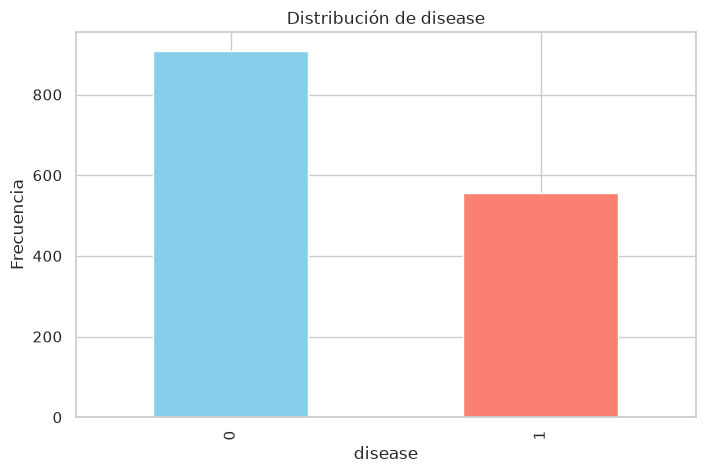

disease
0   62.01
1   37.99
Name: proportion, dtype: float64

In [ ]:
df[TARGET].value_counts().plot(
    kind="bar", color=["skyblue", "salmon"], title=f"Distribución de {TARGET}"
)
plt.ylabel("Frecuencia")
plt.show()

(df[TARGET].value_counts(normalize=True) * 100).round(2)


### 6.2 Variables numéricas

In [128]:
df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1462.00,53.32,9.21,34.00,46.00,54.00,60.00,76.00
rest_bp,1422.00,129.43,16.83,94.00,120.00,129.00,140.00,180.00
chol,1420.00,238.37,47.29,126.00,204.00,233.00,267.00,354.00
max_hr,1443.00,151.10,23.44,71.00,138.50,157.00,169.00,194.00
old_peak,1464.00,0.95,1.11,0.00,0.00,0.60,1.50,5.60
slope,1466.00,1.53,0.60,1.00,1.00,1.00,2.00,3.00
ca,1437.00,0.57,0.87,0.00,0.00,0.00,1.00,3.00


In [ ]:
resumen_num = pd.DataFrame(
    {
        "skewness": df[numerical_columns].skew(),
        "kurtosis": df[numerical_columns].kurtosis(),
        "valores_unicos": df[numerical_columns].nunique(),
    }
)
resumen_num

,skewness,kurtosis,valores_unicos
age,-0.07,-0.80,38
rest_bp,0.61,0.53,40
chol,0.37,-0.21,99
max_hr,-0.79,0.26,73
old_peak,1.41,1.95,31
slope,0.67,-0.50,3
ca,1.39,0.87,4


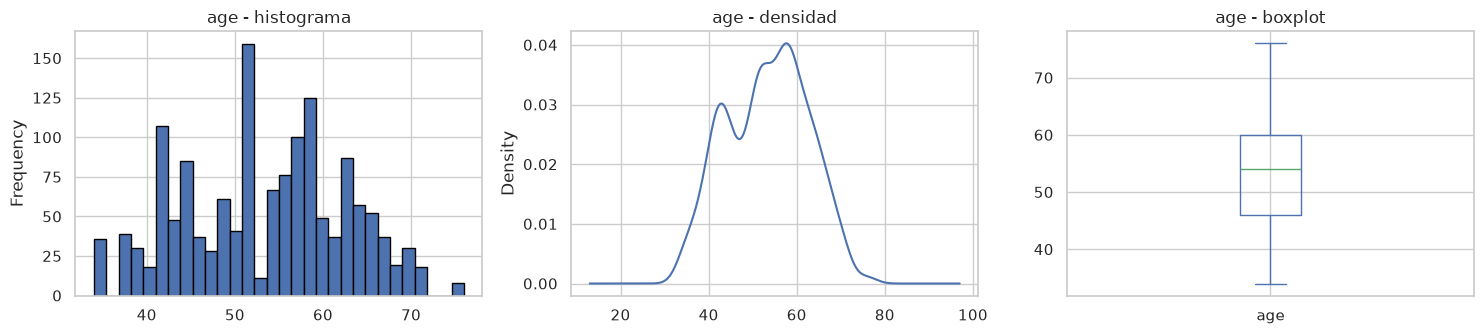

age: Shapiro-Wilk p-value = 0.0000 (no parece normal)


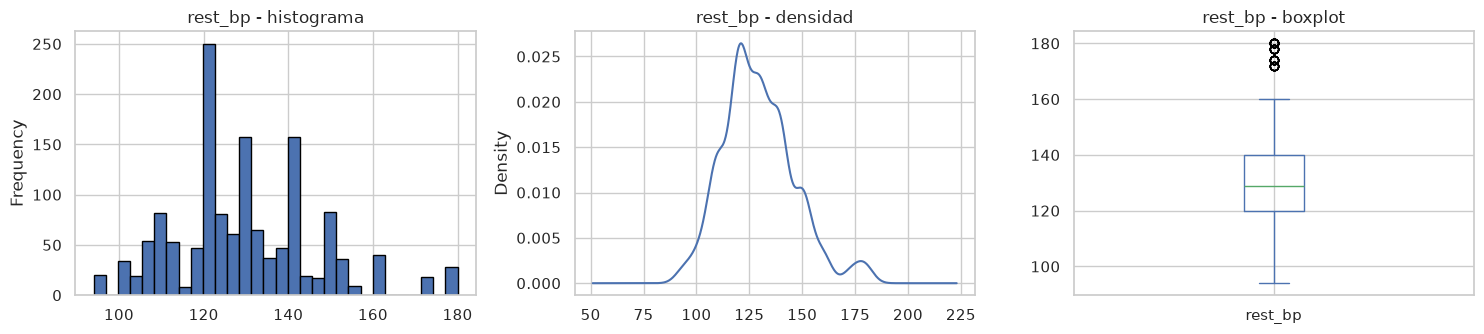

rest_bp: Shapiro-Wilk p-value = 0.0000 (no parece normal)


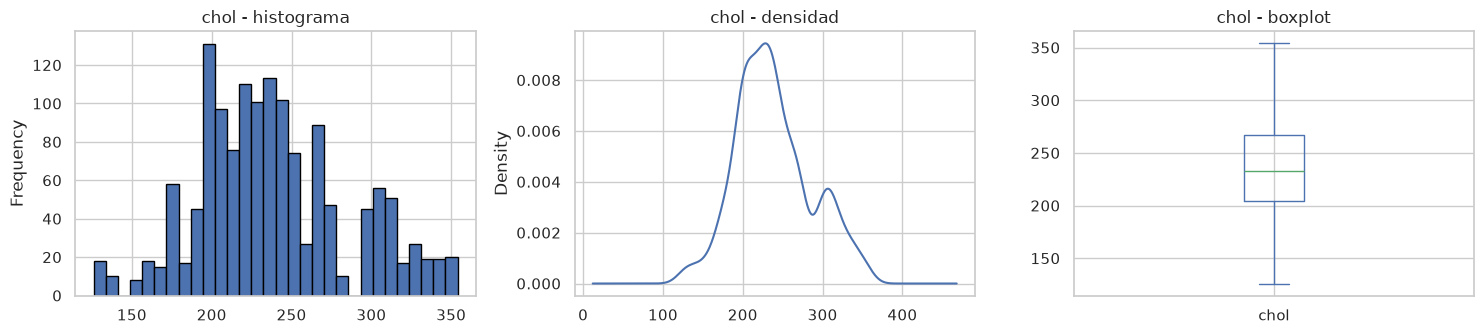

chol: Shapiro-Wilk p-value = 0.0000 (no parece normal)


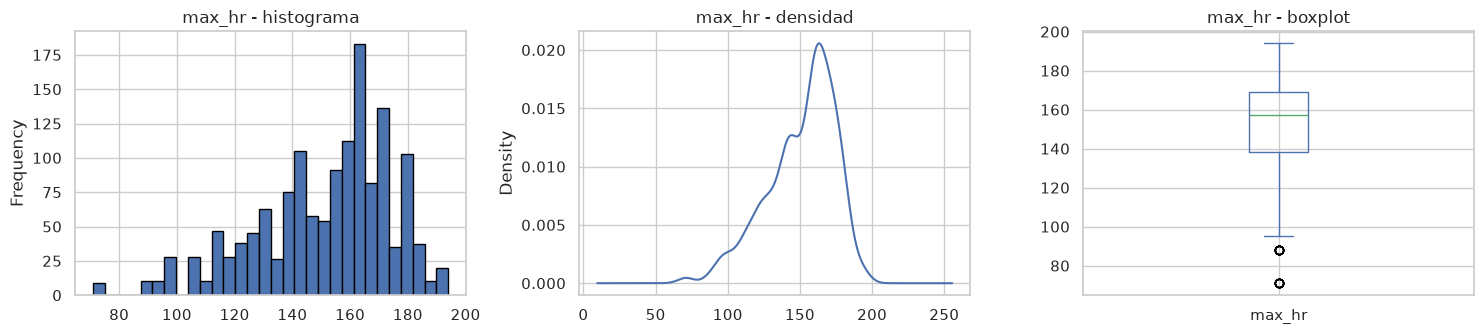

max_hr: Shapiro-Wilk p-value = 0.0000 (no parece normal)


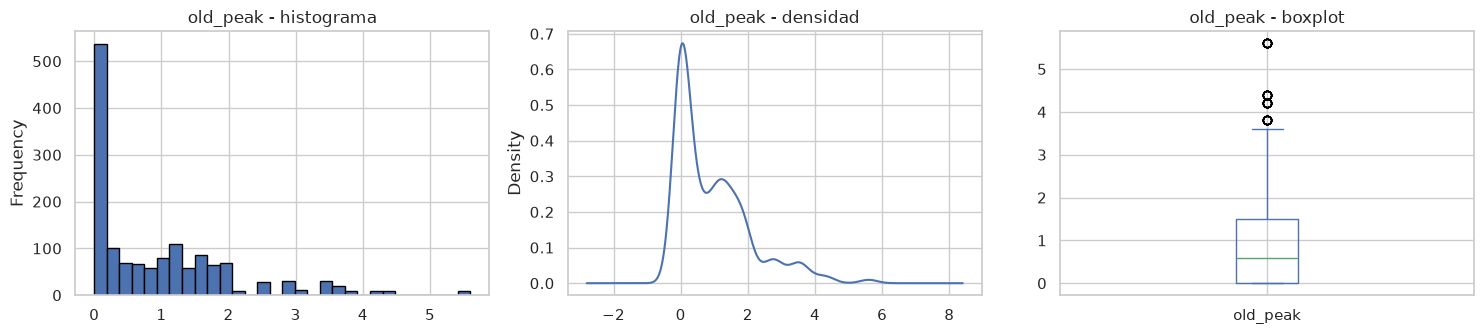

old_peak: Shapiro-Wilk p-value = 0.0000 (no parece normal)


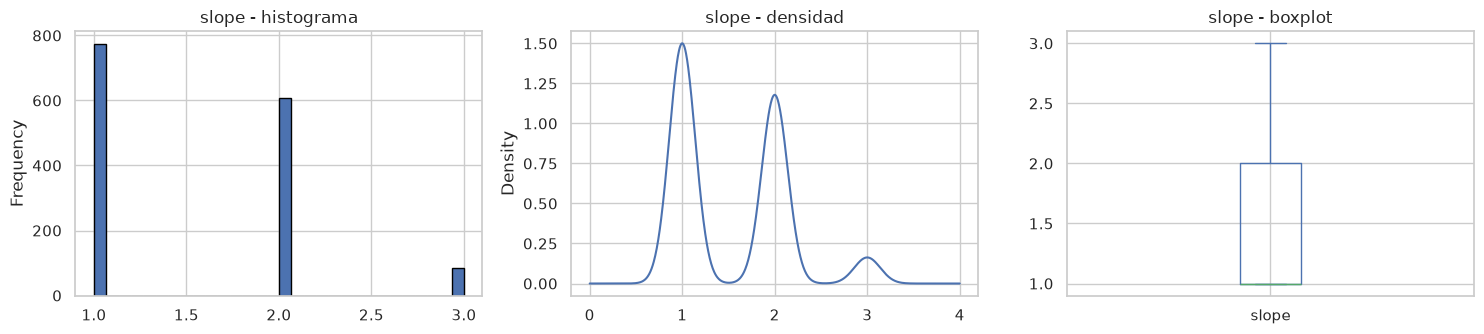

slope: Shapiro-Wilk p-value = 0.0000 (no parece normal)


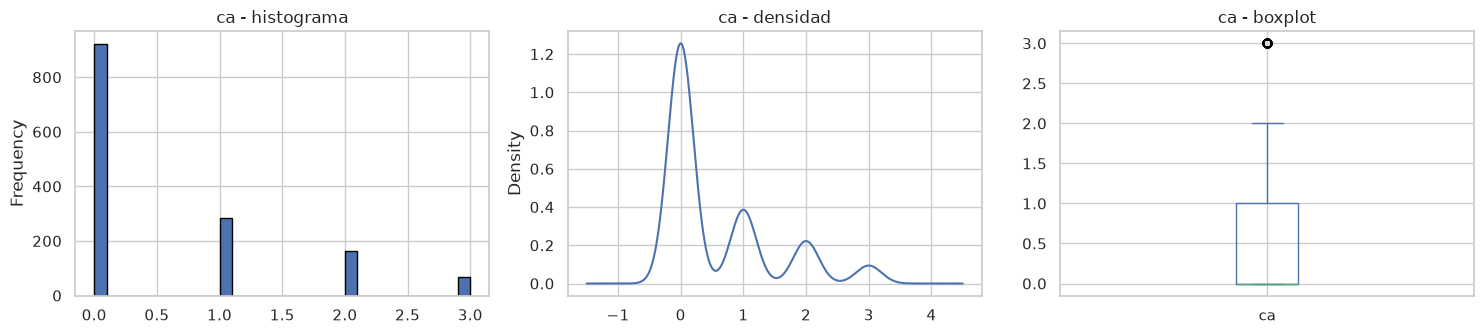

ca: Shapiro-Wilk p-value = 0.0000 (no parece normal)


In [ ]:
for col in numerical_columns:
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))
    df[col].plot(
        kind="hist", bins=30, edgecolor="black", ax=axes[0], title=f"{col} - histograma"
    )
    df[col].plot(kind="kde", ax=axes[1], title=f"{col} - densidad")
    df[col].plot(kind="box", ax=axes[2], title=f"{col} - boxplot")
    plt.tight_layout()
    plt.show()

    muestra = df[col].dropna()
    if len(muestra) > 3:
        stat, p = stats.shapiro(
            muestra.sample(min(len(muestra), 5000), random_state=42)
        )
        print(
            f"{col}: Shapiro-Wilk p-value = {p:.4f} "
            f"({'probable distribución normal' if p > 0.05 else 'no parece normal'})"
        )

### 6.3 Variables categóricas

sex
Male      940
Female    483
NaN        43
2345        0
45          0
765         0
Name: count, dtype: int64


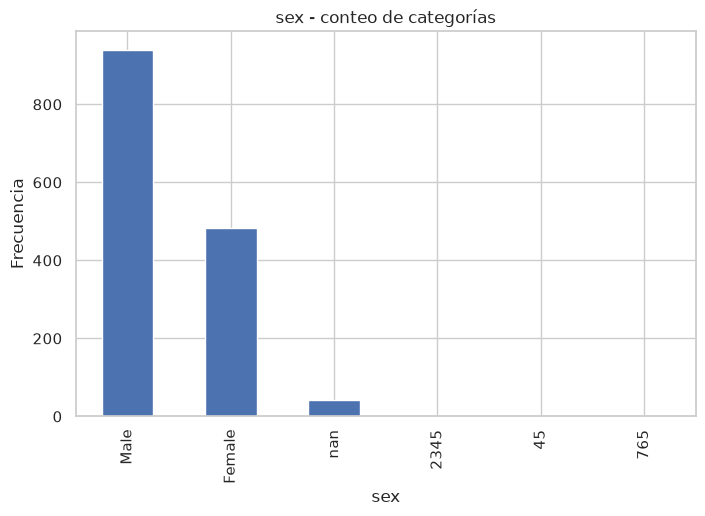

chest_pain
asymptomatic    602
nonanginal      459
nontypical      281
typical          82
NaN              42
2345              0
2435              0
3456              0
Name: count, dtype: int64


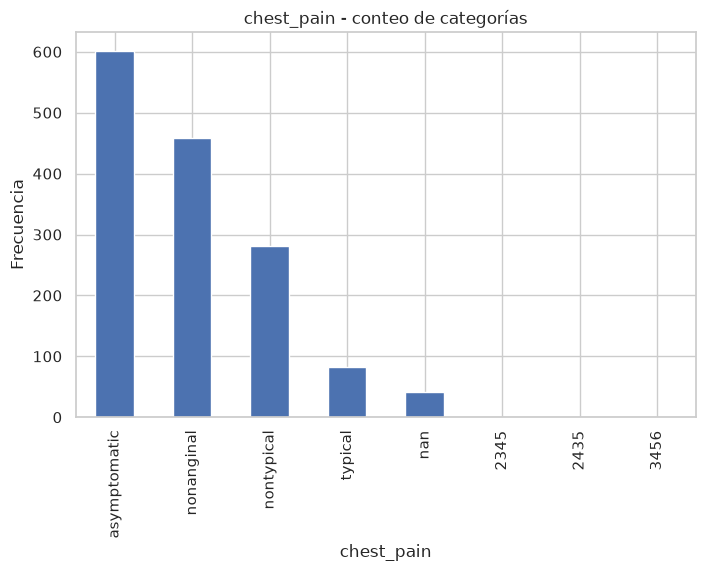

fbs
False    1246
True      174
<NA>       46
Name: count, dtype: Int64


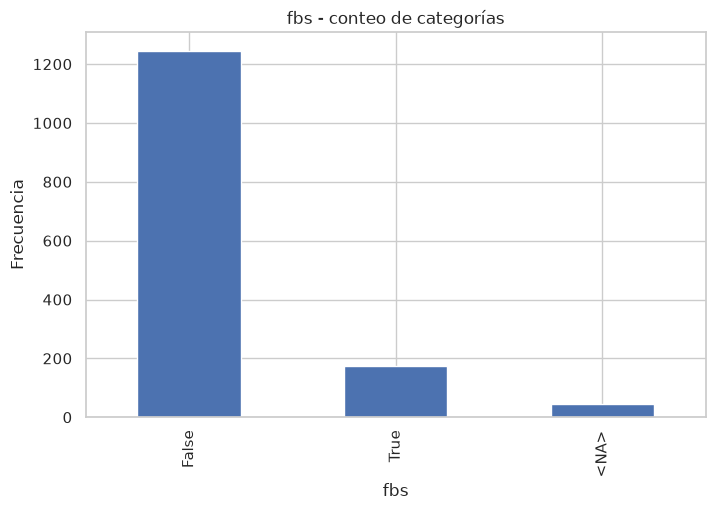

rest_ecg
normal                           1385
NaN                                46
ST-T wave abnormality              35
3563                                0
36653                               0
435647                              0
5653                                0
5678                                0
left ventricular hypertrophy        0
Name: count, dtype: int64


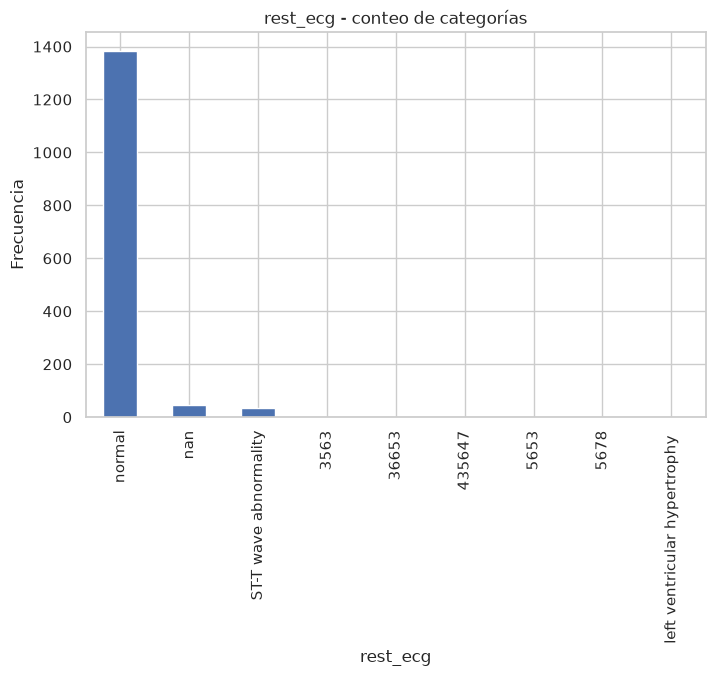

exang
False    1027
True      439
Name: count, dtype: Int64


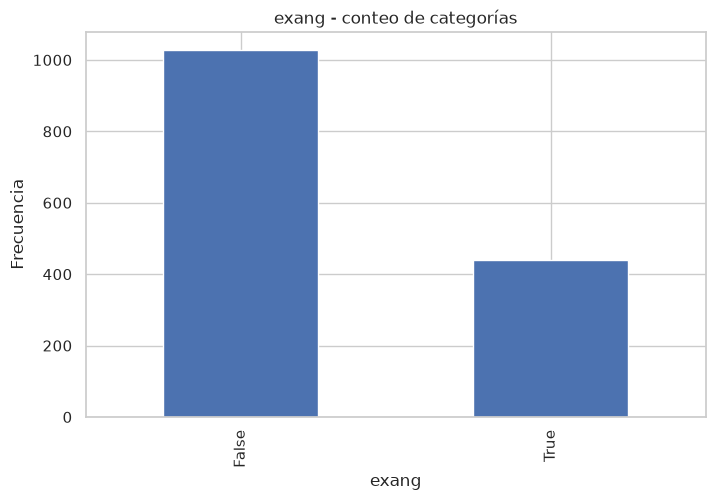

thal
normal        826
reversable    560
fixed          72
NaN             8
365635463       0
53646           0
56              0
87654           0
Name: count, dtype: int64


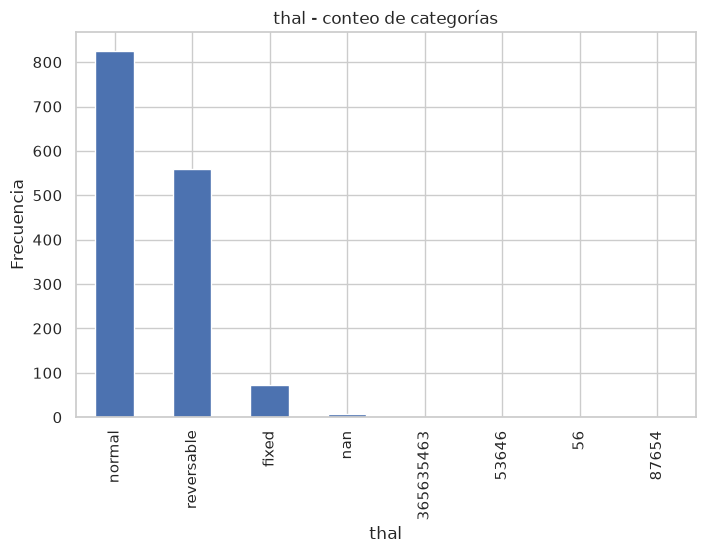

In [ ]:
for col in categorical_columns:
    print(df[col].value_counts(dropna=False))
    df[col].value_counts(dropna=False).plot(
        kind="bar", title=f"{col} - conteo de categorías"
    )
    plt.ylabel("Frecuencia")
    plt.show()

## 🔗 7. Análisis Bivariable

### 7.1 Correlación entre variables numéricas

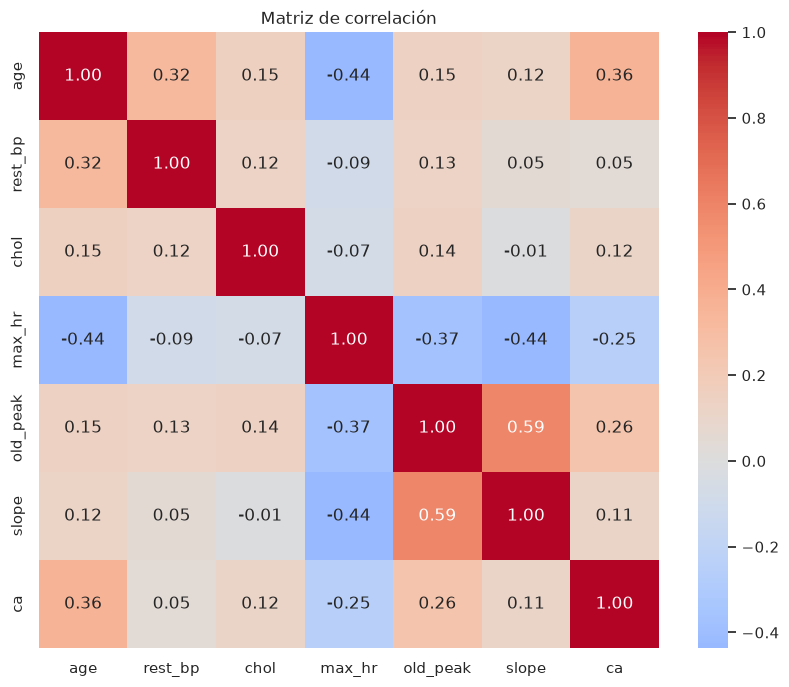

In [132]:
plt.figure(figsize=(10, 8))
corr = df[numerical_columns + [TARGET]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

### 7.2 Variables numéricas vs target

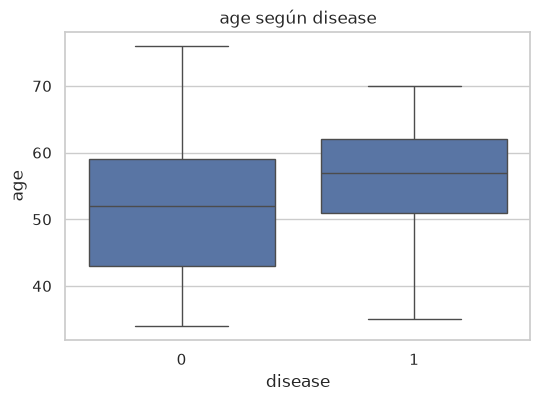

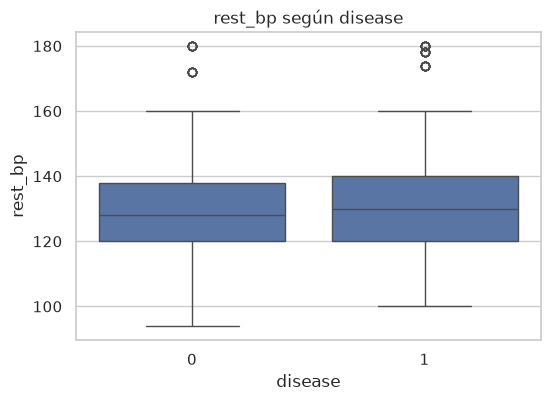

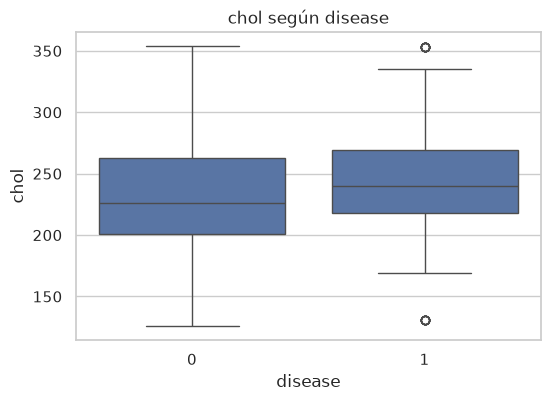

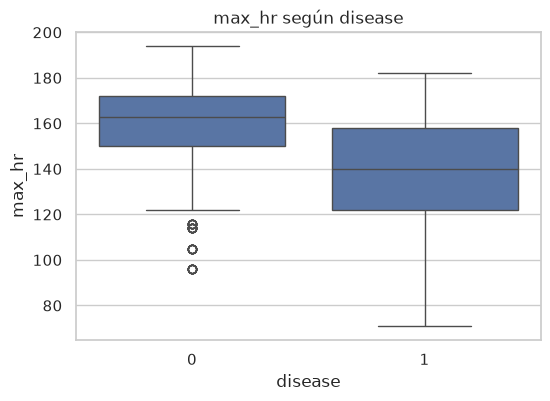

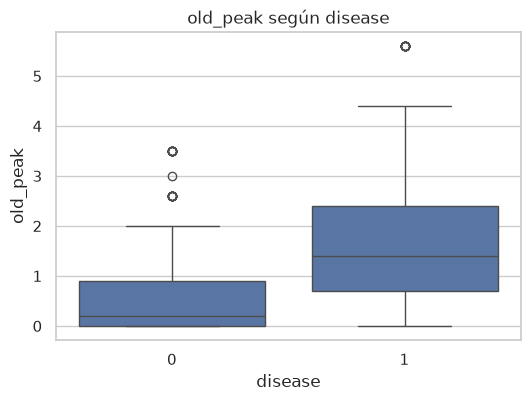

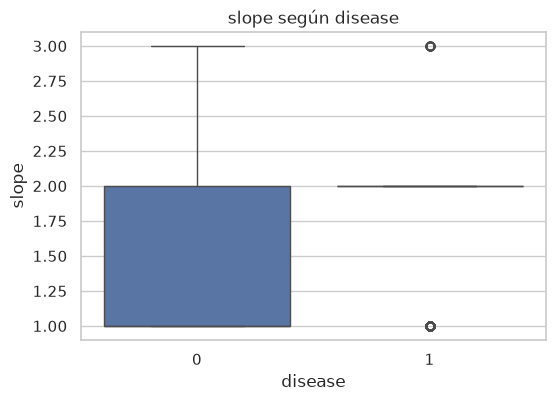

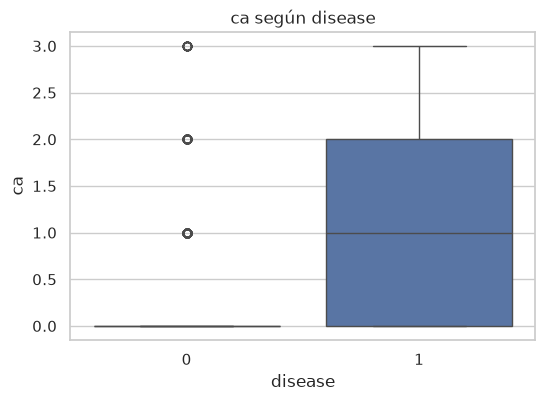

In [133]:
for col in numerical_columns:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x=TARGET, y=col)
    plt.title(f"{col} según {TARGET}")
    plt.show()

### 7.3 Variables categóricas vs target

disease     0     1
sex                
Female  78.90 21.10
Male    53.60 46.40


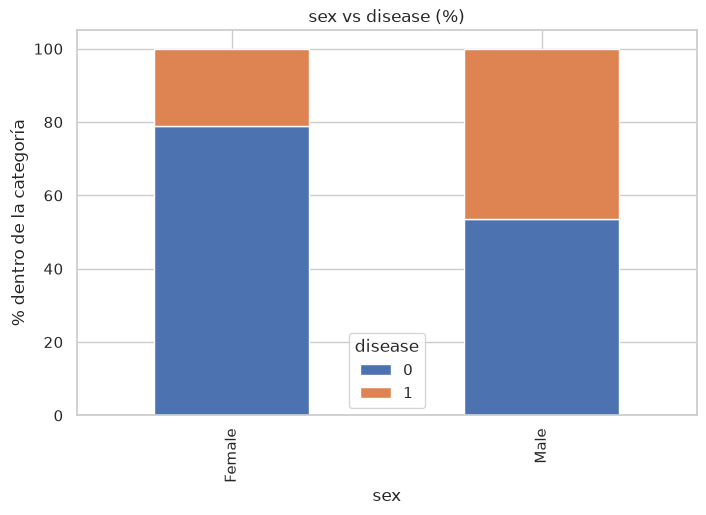

sex: Chi2 p-value = 0.0000 (asociación significativa)

disease          0     1
chest_pain              
asymptomatic 33.70 66.30
nonanginal   82.60 17.40
nontypical   91.10  8.90
typical      57.30 42.70


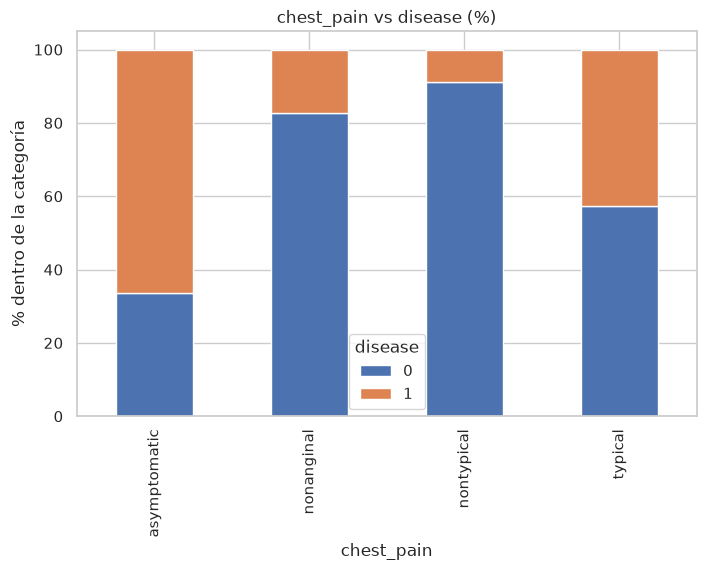

chest_pain: Chi2 p-value = 0.0000 (asociación significativa)

disease     0     1
fbs                
False   61.90 38.10
True    63.80 36.20


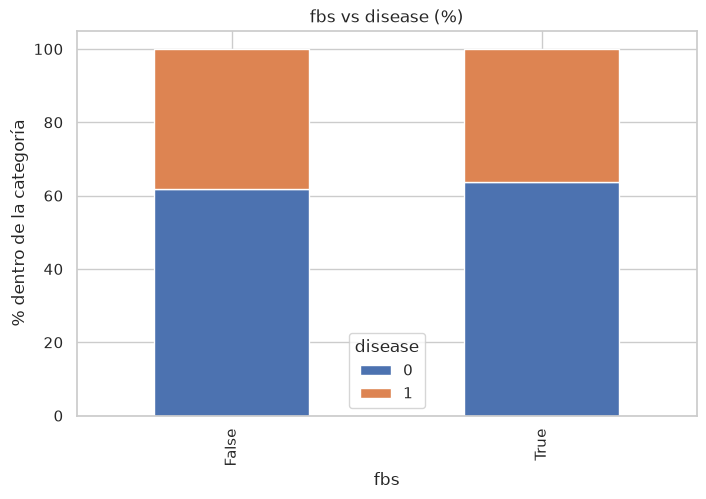

fbs: Chi2 p-value = 0.6859 (sin asociación significativa)

disease                   0     1
rest_ecg                         
ST-T wave abnormality 22.90 77.10
normal                63.20 36.80


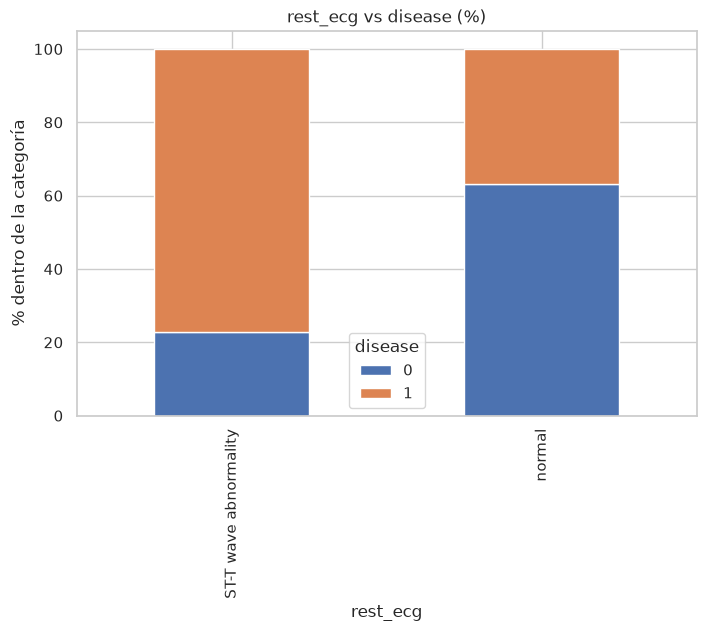

rest_ecg: Chi2 p-value = 0.0000 (asociación significativa)

disease     0     1
exang              
False   77.90 22.10
True    24.80 75.20


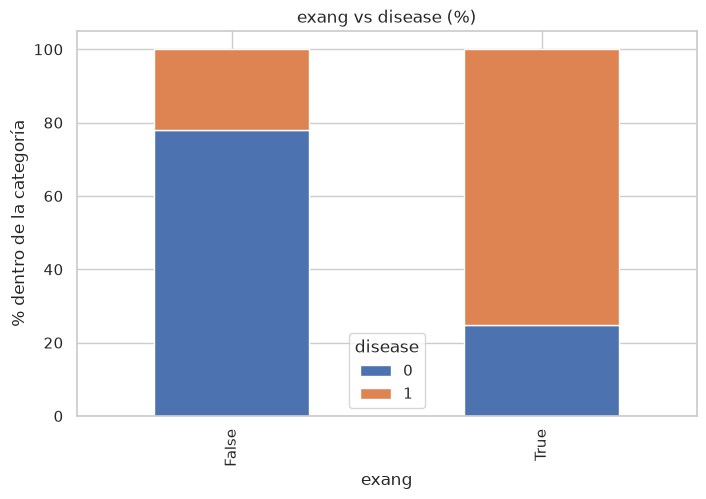

exang: Chi2 p-value = 0.0000 (asociación significativa)

disease        0     1
thal                  
fixed      37.50 62.50
normal     84.90 15.10
reversable 32.30 67.70


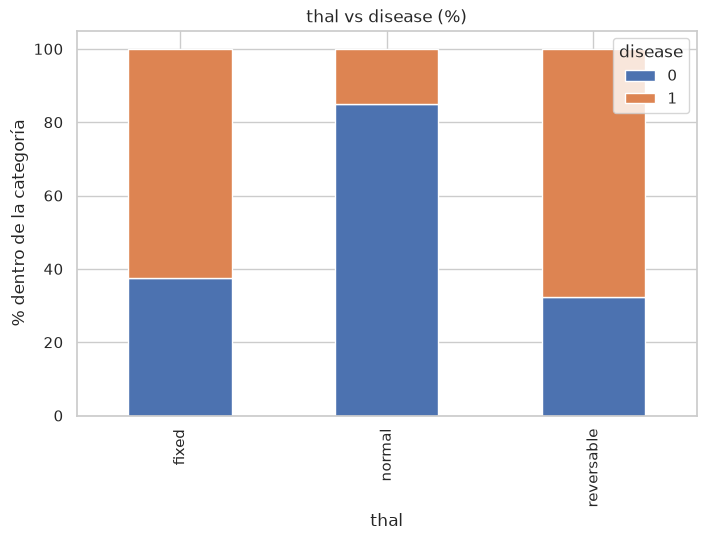

thal: Chi2 p-value = 0.0000 (asociación significativa)



In [134]:
for col in categorical_columns:
    tabla = pd.crosstab(df[col], df[TARGET], normalize="index") * 100
    print(tabla.round(1))
    tabla.plot(kind="bar", stacked=True, title=f"{col} vs {TARGET} (%)")
    plt.ylabel("% dentro de la categoría")
    plt.legend(title=TARGET)
    plt.show()

    contingencia = pd.crosstab(df[col], df[TARGET])
    chi2, p, dof, _ = stats.chi2_contingency(contingencia)
    print(
        f"{col}: Chi2 p-value = {p:.4f} "
        f"({'asociación significativa' if p < 0.05 else 'sin asociación significativa'})\n"
    )

## 🧩 8. Análisis Multivariable

### 8.1 Pairplot

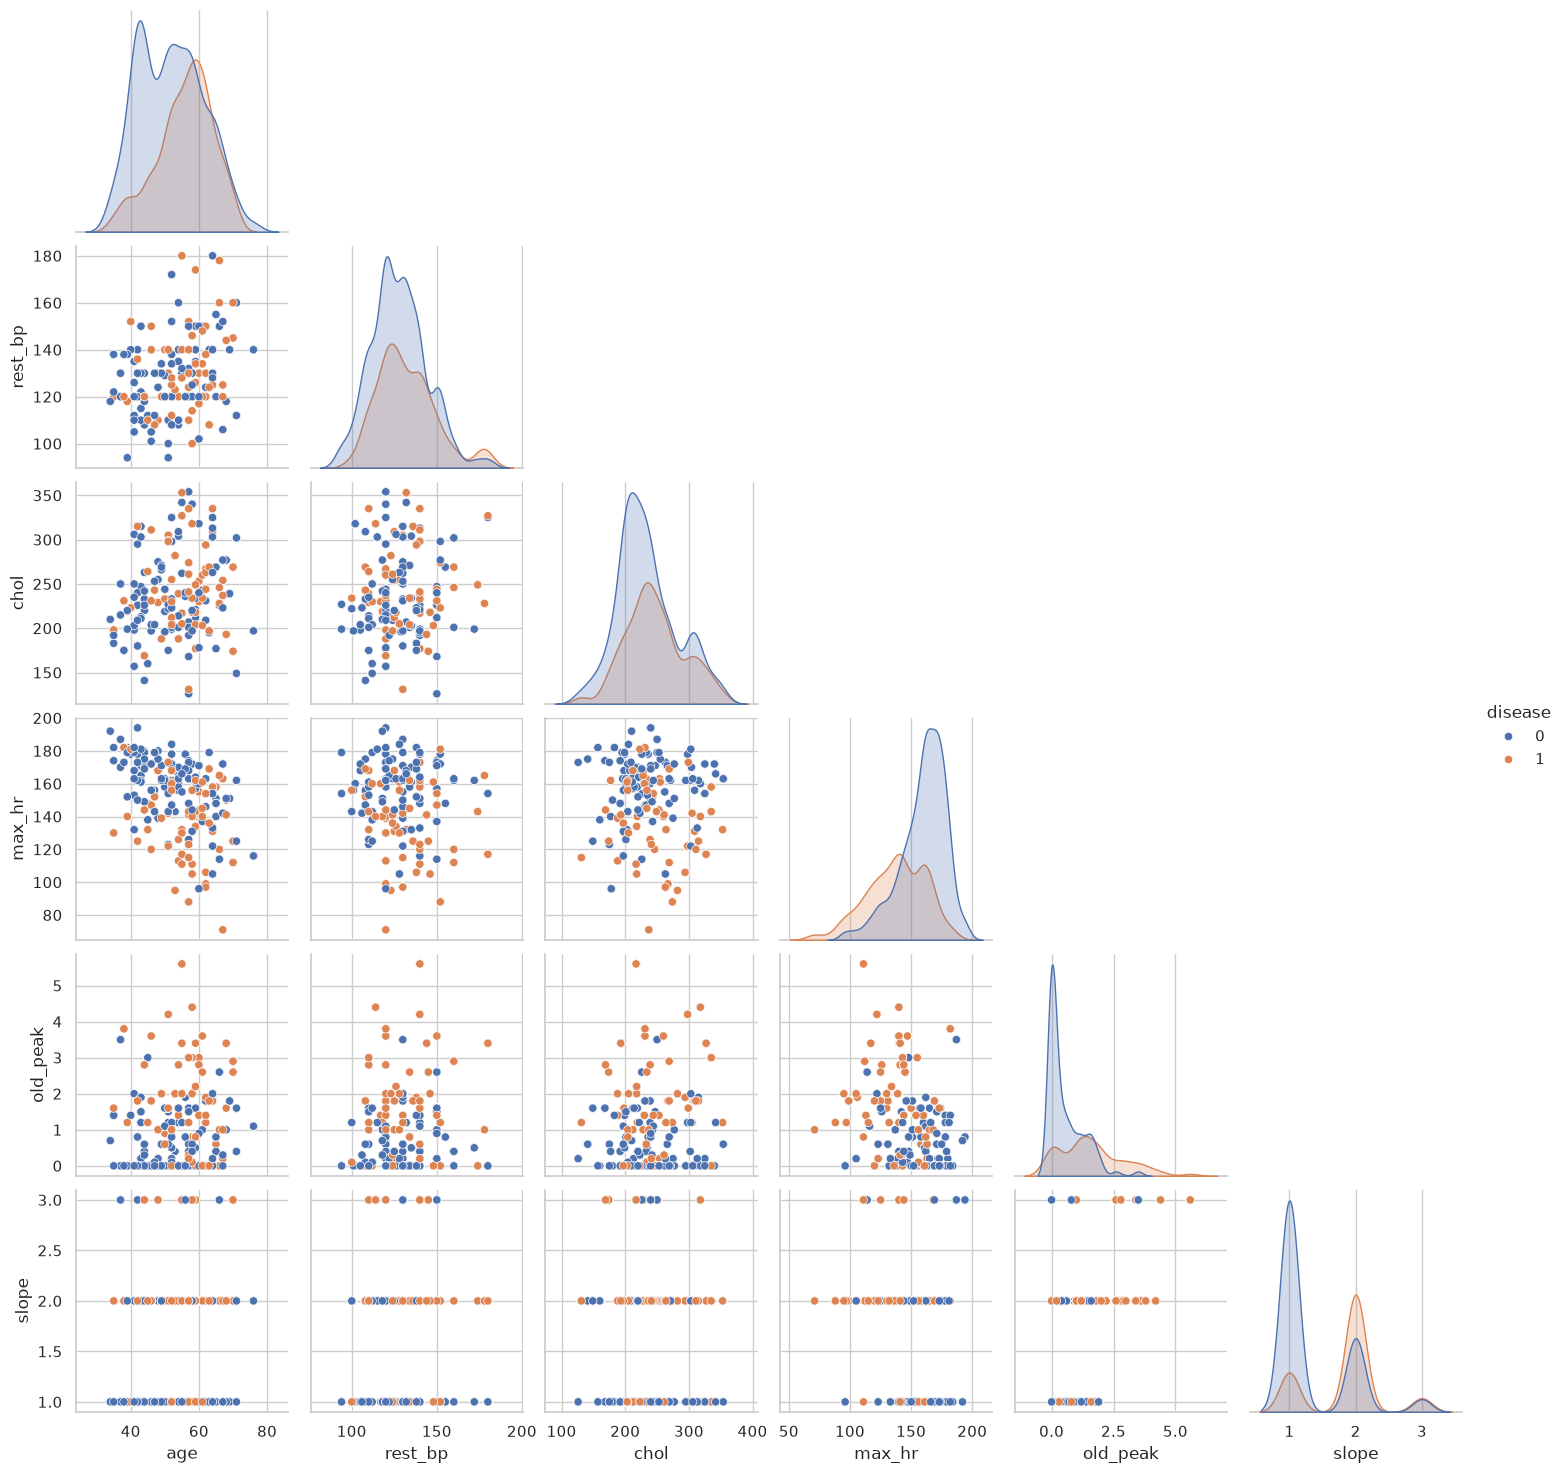

In [135]:
# Limita columnas si tienes muchas variables numéricas, para legibilidad
cols_pairplot = numerical_columns[:6] + [TARGET]
sns.pairplot(df[cols_pairplot], hue=TARGET, diag_kind="kde", corner=True)
plt.show()

### 8.2 Reducción de dimensionalidad (PCA) — opcional

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df[numerical_columns].dropna()
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
componentes = pca.fit_transform(X_scaled)

plt.figure(figsize=(7, 5))
plt.scatter(
    componentes[:, 0],
    componentes[:, 1],
    c=df.loc[X.index, TARGET].astype("category").cat.codes,
    cmap="coolwarm",
    alpha=0.7,
)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)")
plt.title("PCA - primeras 2 componentes")
plt.show()

print("Varianza explicada:", pca.explained_variance_ratio_)

ModuleNotFoundError: No module named 'sklearn'

## ✅ 9. Reglas de validación de datos propuestas

_Completar según los resultados obtenidos arriba:_

- **Rangos válidos** por variable numérica (min/max observados vs. límites fisiológicamente posibles).
- **Categorías permitidas** por variable categórica (valores únicos esperados).
- **Nulos**: definir si `TARGET` no puede tener nulos; política de imputación para las demás.
- **Duplicados**: si existen filas duplicadas, definir si se eliminan o se conservan.
- **Tipos de dato** esperados por columna (para validación en el pipeline, ej. con `pandera` o `great_expectations`).

## 🩺 10. ¿Modelo heurístico viable?

Antes de un modelo de ML, evalúa un baseline simple:

In [ ]:
# Baseline 1: predicción por clase mayoritaria
clase_mayoritaria = df[TARGET].mode()[0]
baseline_acc = (df[TARGET] == clase_mayoritaria).mean()
print(f"Accuracy baseline (clase mayoritaria): {baseline_acc:.3f}")

_Con base en el análisis bivariable (correlaciones y pruebas Chi²), identifica la variable con
mayor asociación al target y evalúa si una regla simple (ej. umbral sobre esa variable) supera el
baseline de clase mayoritaria. Documenta la conclusión aquí._

## 📝 11. Conclusiones

- **Resumen del dataset:** (filas, columnas, % nulos general, duplicados)
- **Variable objetivo:** (¿balanceada o desbalanceada?)
- **Variables numéricas más relevantes:** (según correlación/boxplots vs target)
- **Variables categóricas más relevantes:** (según Chi² vs target)
- **Transformaciones sugeridas:** (normalización, codificación, tratamiento de outliers, imputación)
- **Datos adicionales útiles:** (si aplica)
- **Viabilidad de modelo heurístico:** (sí/no y por qué)